# Minimum-time swing-up: a worked solution

The worked solution to exercise 1 of tutorial 2. Attempt it there first.

The pendulum of tutorial 2 has a motor at the pivot, capped at
`u_max = 10`. Instead of minimizing control effort over a fixed five-second
horizon, we ask for the *fastest* swing-up from hanging down to upright:

$$
\begin{aligned}
\min_{\theta, \omega, u,\, \Delta t}\quad & N \Delta t \\
\text{s.t.}\quad
  & \theta_i - \theta_{i-1} - \tfrac{\Delta t}{2}(\omega_i + \omega_{i-1}) = 0,
  && i = 1, \dots, N, \\
  & \omega_i - \omega_{i-1} - \tfrac{\Delta t}{2}\big(f(\theta_i,\omega_i,u_i)
    + f(\theta_{i-1},\omega_{i-1},u_{i-1})\big) = 0, && i = 1, \dots, N, \\
  & -u_{\max} \le u_i \le u_{\max}, && i = 0, \dots, N, \\
  & \theta_0 = 0,\quad \omega_0 = 0,\quad \theta_N = \pi,\quad \omega_N = 0 .
\end{aligned}
$$

The horizon enters through $\Delta t$, the step length, which is now a
decision variable rather than a constant. This is the same device Goddard's
rocket uses for its free final time: minimizing the step minimizes the
horizon, and the step multiplies the states inside every dynamics row, so
those constraints become nonlinear in a variable they did not previously
contain. The generators are written exactly as before.

In [1]:
using CUDA, CUDSS, ExaModels, MadNLP, MadNLPGPU
using Plots
gr(fmt = :svg)

function swingup_mintime(N; u_max = 10.0, backend = nothing)
    c = ExaCore(; backend = backend)
    @add_var(c, dt, 1; start = 5.0 / N, lvar = 0.0)
    @add_var(c, θ, 0:N; start = [π * i / N for i = 0:N])
    @add_var(c, ω, 0:N; start = fill(π / 5.0, N + 1))
    @add_var(c, u, 0:N; lvar = -u_max, uvar = u_max, start = zeros(N + 1))

    @add_obj(c, dt[1])

    @add_con(c, θ[i] - θ[i-1] - dt[1] / 2 * (ω[i] + ω[i-1]) for i = 1:N)
    @add_con(c,
        ω[i] - ω[i-1] - dt[1] / 2 *
        ((u[i] - 9.81 * sin(θ[i]) - 0.1 * ω[i]) +
         (u[i-1] - 9.81 * sin(θ[i-1]) - 0.1 * ω[i-1])) for i = 1:N)

    @add_con(c, θ[0])
    @add_con(c, ω[0])
    @add_con(c, θ[N] - π)
    @add_con(c, ω[N])

    return ExaModel(c)
end

N = 1000
model_mt = swingup_mintime(N; backend = CUDABackend())
result_mt = madnlp(model_mt; max_iter = 1000, tol = 1e-8)

(status = result_mt.status, minimum_time_s = N * result_mt.objective)

This is MadNLP version v0.10.1, running with cuDSS v0.8.0

Number of nonzeros in constraint Jacobian............:    12004
Number of nonzeros in Lagrangian Hessian.............:    34000

Total number of variables............................:     3004
                     variables with only lower bounds:        1
                variables with lower and upper bounds:     1001
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:     2004
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:     2004
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du inf_compl lg(mu) lg(rg) alpha_pr ir ls
   0  9.9999900e-03 6.28e-01 0.00e+00 1.00e+01  -1.0     -   0.00e+00  0  0 
   1  9.9999851e-03 6.28e-01 1.62e-01 3.85e-03  -1.0     -   2.00e-07  2  2h
   2 

(status = MadNLP.SOLVE_SUCCEEDED, minimum_time_s = 1.2903998125995704)

The trajectory and the torque:

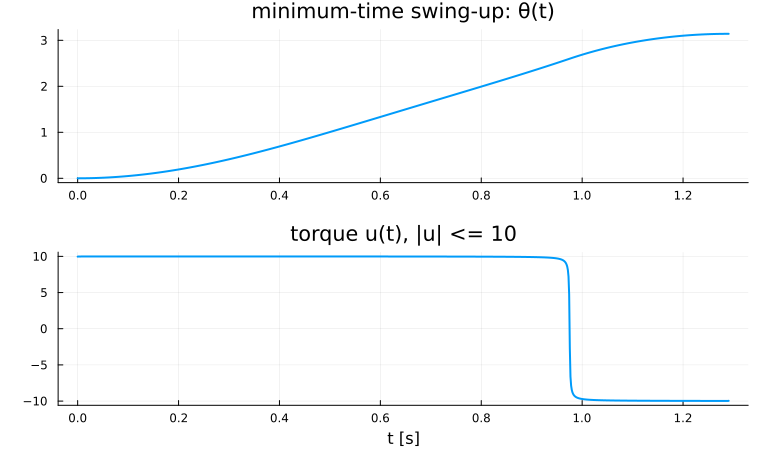

In [2]:
θ_mt = Array(solution(result_mt, model_mt.refs.θ))
u_mt = Array(solution(result_mt, model_mt.refs.u))
t_mt = range(0, N * result_mt.objective; length = N + 1)

plot(t_mt, [θ_mt u_mt];
    layout = (2, 1), legend = false, lw = 2, size = (760, 460),
    left_margin = 4Plots.mm, bottom_margin = 4Plots.mm,
    title = ["minimum-time swing-up: θ(t)" "torque u(t), |u| <= 10"],
    xlabel = ["" "t [s]"])

The torque sits at its limit and switches sign sharply, where minimizing
effort spread a gentler torque over the full five seconds. Minimizing time
pushes the actuator against its bounds; minimizing effort keeps it away
from them.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*